# Model monitor — live Kaggle performance per shipped model

Pulls the episode listings for every submission in `MODELS` (via
`rl.kaggle_ingest.list_episodes` — needs `~/.kaggle/kaggle.json` credentials),
labels each episode with its model, and tracks **leaderboard score** and
**rolling win rate** over time.

Re-run all cells to refresh — listings are fetched live (they go stale, so
nothing is cached). Add a row to `MODELS` whenever a new agent ships.


In [ ]:
import sys
from pathlib import Path

# repo-root bootstrap: the kernel's cwd is notebooks/
_ROOT = Path.cwd()
while not (_ROOT / "rl").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from rl.kaggle_ingest import list_episodes

# Ship history: submission id -> model label (docs/MILESTONES.md ship history).
MODELS = {
    54586430: "solver-on (M7.4a rules)",
    54616196: "M7.5 partial fixes (rules)",
    54621283: "solver+5fixes (M7.5 rules)",
    54779834: "osv3_plan0c (M11 neural)",
    54790886: "osv3_plan2 (M14 setup-plans)",
    54793851: "osv3h_plan1 (M15 hand-aware)",
}

# Validated categorical palette (dataviz skill, light surface) — color follows
# the MODEL identity, in fixed slot order; never re-assigned when filtering.
PALETTE = ["#2a78d6", "#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834"]
COLOR = {sid: PALETTE[i % len(PALETTE)] for i, sid in enumerate(MODELS)}
INK, INK2, GRID = "#333333", "#666666", "#e5e5e5"


In [24]:
def fetch_model(sub_id: int, label: str) -> pd.DataFrame:
    """One row per episode, from OUR seat's perspective."""
    df = pd.DataFrame(list_episodes(submission_id=sub_id).to_dicts())
    if df.empty:
        return pd.DataFrame()
    ours0 = df["submission_id_0"] == sub_id
    df["our_reward"] = df["reward_0"].where(ours0, df["reward_1"])
    df["opp_reward"] = df["reward_1"].where(ours0, df["reward_0"])
    df["our_score"] = df["updated_score_0"].where(ours0, df["updated_score_1"])
    df["time"] = pd.to_datetime(df["end_time"].fillna(df["create_time"]),
                                format="mixed", utc=True)
    df["win"] = (df["our_reward"] > df["opp_reward"]).astype(float)
    df.loc[df["our_reward"] == df["opp_reward"], "win"] = 0.5
    df["model"] = label
    df["submission"] = sub_id
    return df.sort_values("time").reset_index(drop=True)


frames = []
for sid, label in MODELS.items():
    d = fetch_model(sid, label)
    print(f"{label}: {len(d)} episodes")
    if not d.empty:
        frames.append(d)
episodes = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


solver-on (M7.4a rules): 45 episodes
M7.5 partial fixes (rules): 96 episodes
solver+5fixes (M7.5 rules): 107 episodes
osv3_plan0c (M11 neural): 31 episodes


In [25]:
# Summary table (also the accessibility table-view for the charts below).
if not episodes.empty:
    summary = (episodes.groupby("model", sort=False)
               .agg(episodes=("episode_id", "count"),
                    wins=("win", lambda w: int((w == 1).sum())),
                    win_rate=("win", "mean"),
                    latest_score=("our_score", lambda s: s.dropna().iloc[-1]
                                  if s.notna().any() else float("nan")),
                    first_seen=("time", "min"),
                    last_seen=("time", "max"))
               .round({"win_rate": 3, "latest_score": 1}))
    display(summary)
else:
    print("no episodes yet for any listed model")


,episodes,wins,win_rate,latest_score,first_seen,last_seen
model,,,,,,
solver-on (M7.4a rules),45,20,0.444,500.0,2026-07-11 22:15:13.153104300+00:00,2026-07-12 19:23:11.884107500+00:00
M7.5 partial fixes (rules),96,42,0.438,502.5,2026-07-12 17:00:10.226614100+00:00,2026-07-17 06:29:41.398335500+00:00
solver+5fixes (M7.5 rules),107,46,0.430,543.4,2026-07-12 20:34:31.851902100+00:00,2026-07-17 11:09:14.395528100+00:00
osv3_plan0c (M11 neural),31,12,0.387,468.2,2026-07-17 09:28:30.429019400+00:00,2026-07-17 11:41:18.346114900+00:00


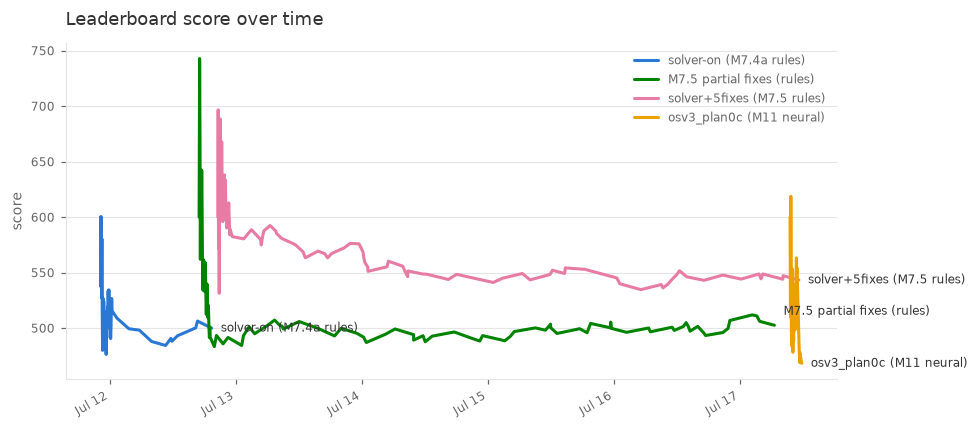

In [26]:
# Chart 1 — leaderboard score over time (one line per model, single axis).
def style_axes(ax, title, ylab):
    ax.set_title(title, color=INK, fontsize=12, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.grid(axis="y", color=GRID, linewidth=0.75)
    ax.tick_params(colors=INK2, labelsize=8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))


def end_labels(ax, entries, min_gap_frac=0.05):
    # Direct labels at line ends: entries = [(x, y, text, color)], shifted
    # vertically so labels never overlap.
    if not entries:
        return
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * min_gap_frac
    order = sorted(range(len(entries)), key=lambda i: entries[i][1])
    placed = []
    for i in order:
        x, y, text, color = entries[i]
        if placed and y - placed[-1] < gap:
            y = placed[-1] + gap
        placed.append(y)
        ax.annotate(text, (x, y), xytext=(6, 0),
                    textcoords="offset points", fontsize=8, color=INK,
                    va="center")


if not episodes.empty:
    fig, ax = plt.subplots(figsize=(9, 4), dpi=110)
    labels = []
    for sid, label in MODELS.items():
        d = episodes[(episodes["submission"] == sid)
                     & episodes["our_score"].notna()]
        if d.empty:
            continue
        marker = "o" if len(d) < 10 else None
        ax.plot(d["time"], d["our_score"], color=COLOR[sid], linewidth=2,
                label=label, solid_capstyle="round", marker=marker,
                markersize=5)
        labels.append((d["time"].iloc[-1], d["our_score"].iloc[-1], label,
                       COLOR[sid]))
    style_axes(ax, "Leaderboard score over time", "score")
    end_labels(ax, labels)
    ax.legend(frameon=False, fontsize=8, labelcolor=INK2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


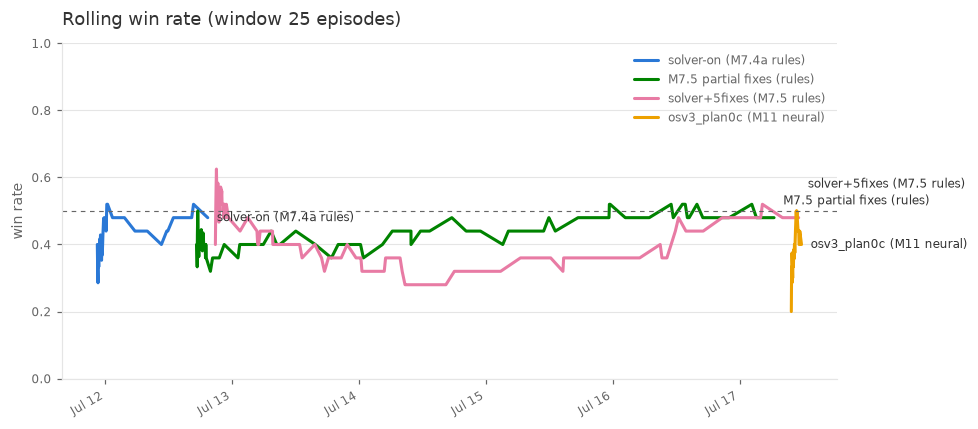

In [27]:
# Chart 2 — rolling win rate (window=25 episodes), one line per model.
WINDOW = 25
if not episodes.empty:
    fig, ax = plt.subplots(figsize=(9, 4), dpi=110)
    labels = []
    for sid, label in MODELS.items():
        d = episodes[episodes["submission"] == sid]
        if len(d) < 5:
            continue
        roll = d["win"].rolling(WINDOW, min_periods=5).mean()
        ax.plot(d["time"], roll, color=COLOR[sid], linewidth=2, label=label,
                solid_capstyle="round")
        labels.append((d["time"].iloc[-1], float(roll.iloc[-1]), label,
                       COLOR[sid]))
    ax.axhline(0.5, color=INK2, linewidth=0.75, linestyle=(0, (4, 4)))
    ax.set_ylim(0, 1)
    style_axes(ax, f"Rolling win rate (window {WINDOW} episodes)", "win rate")
    end_labels(ax, labels)
    ax.legend(frameon=False, fontsize=8, labelcolor=INK2)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
